In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

#**Data Wrangling**

##Hadling missing values

In [2]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

df.dropna(subset=["date_added", "rating", "duration"], inplace=True)

print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


##Converting Data Types

In [3]:
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())
print(df["date_added"].dtype)
print(df["date_added"].head())

datetime64[ns]
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]


##Splitting Duration Column

In [4]:
df["duration_minutes"] = df[df["type"] == "Movie"]["duration"].str.replace(" min", "").astype(float)
df["duration_seasons"] = df[df["type"] == "TV Show"]["duration"].str.replace(" Seasons", "").str.replace(" Season", "").astype(float)

print(df[["type", "duration", "duration_minutes", "duration_seasons"]].head(10))

      type   duration  duration_minutes  duration_seasons
0    Movie     90 min              90.0               NaN
1  TV Show  2 Seasons               NaN               2.0
2  TV Show   1 Season               NaN               1.0
3  TV Show   1 Season               NaN               1.0
4  TV Show  2 Seasons               NaN               2.0
5  TV Show   1 Season               NaN               1.0
6    Movie     91 min              91.0               NaN
7    Movie    125 min             125.0               NaN
8  TV Show  9 Seasons               NaN               9.0
9    Movie    104 min             104.0               NaN


#**Business Questions**

##Has Netflix been growing its catalog over the years or is growth slowing down?

In [5]:
content_per_year = df.groupby(df["date_added"].dt.year)["title"].count()
print(content_per_year)

date_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: title, dtype: int64


##Finding:
Netflix added very little content between 2008 and 2015, with fewer than 100 titles per year. Starting in 2016, the platform experienced rapid catalog growth, peaking at 2,016 titles added in 2019. Growth slowed in 2020 and 2021, though 2021 data may be incomplete as the dataset does not cover the full year.

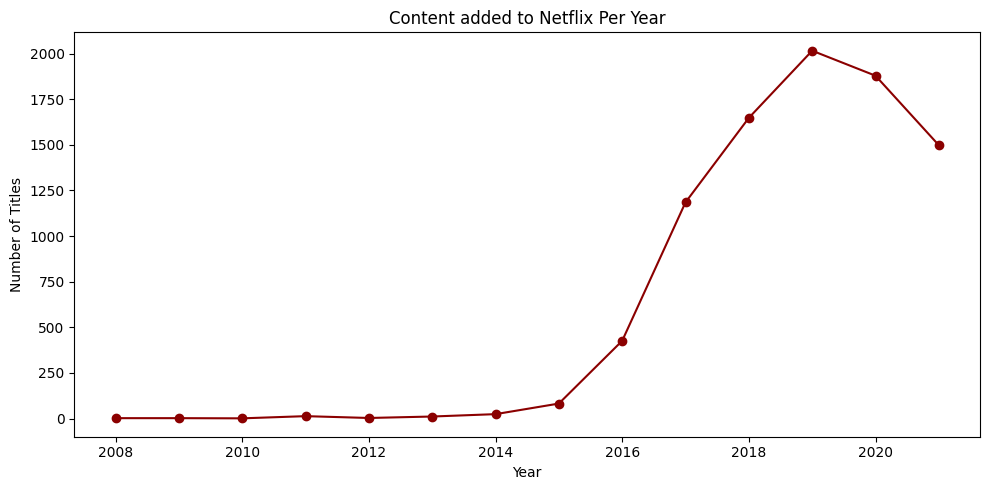

In [6]:
ax= content_per_year.plot(kind = "line",
                     title = "Content added to Netflix Per Year",
                     xlabel = "Year",
                     ylabel = "Number of Titles",
                     color = "darkred",
                     marker = "o",
                     figsize = (10,5))

plt.tight_layout()
plt.show()

##Business Insight:
Netflix's rapid catalog expansion between 2016 and 2019 suggests a period of heavy investment in content acquisition. The slowdown in 2020 and 2021 may reflect a strategic shift toward quality over quantity, or the impact of the COVID-19 pandemic on production. Netflix should monitor whether this trend continues, as a declining catalog growth rate could affect subscriber retention.

##How has the balance between Movies and TV Shows shifted over the years?

In [7]:
content_type = df.groupby([df["date_added"].dt.year, "type"]) ["title"].count().unstack()
print(content_type)

type         Movie  TV Show
date_added                 
2008           1.0      1.0
2009           2.0      NaN
2010           1.0      NaN
2011          13.0      NaN
2012           3.0      NaN
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         251.0    175.0
2017         836.0    349.0
2018        1237.0    411.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


##Finding:
In the early years, the catalog consisted almost exclusively of Movies. After 2016, Netflix began investing more in TV Shows, peaking between 2019 and 2020. However, even with growth from near zero to almost 600 titles, the increase in Movies was significantly larger, maintaining their dominance in the catalog.

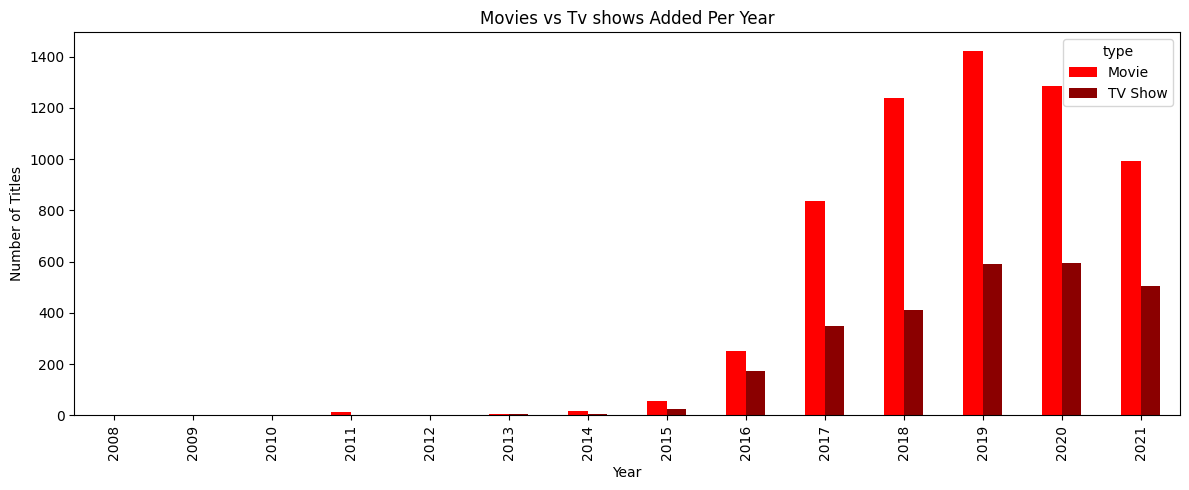

In [8]:
content_type.plot(kind = "bar",
                  title = "Movies vs Tv shows Added Per Year",
                  xlabel = "Year",
                  ylabel = "Number of Titles",
                  color = ["red", "darkred"],
                  figsize = (12,5))

plt.tight_layout()
plt.show()

##Business insight:
While Movies continue to dominate Netflix's catalog, the steady growth of TV Shows since 2016 suggests a strategic shift toward serialized content. Netflix should evaluate whether this trend aligns with audience consumption patterns, as the data alone does not indicate which format drives higher engagement or subscriber retention.

##Which countries are the largest content producers and where should Netflix expand local production?

In [9]:
content_by_country = df[df["country"] != "Unknown"]["country"].value_counts().head(10)
print(content_by_country)

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


##Finding:
The United States is by far the largest content producer with 2,809 titles, followed by India (972) and the United Kingdom (418). The remaining countries produce significantly less content, with numbers dropping sharply after the top three.

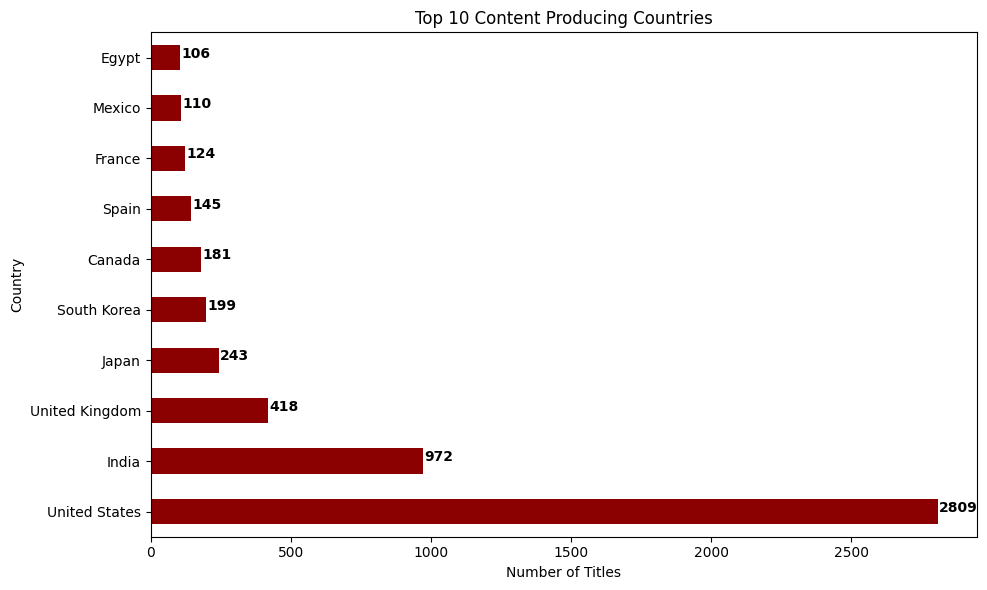

In [19]:
ax = content_by_country.plot(kind = "barh",
                        title = "Top 10 Content Producing Countries",
                        xlabel = "Number of Titles",
                        ylabel = "Country",
                        color = "darkred",
                        figsize = (10,6))
for i, v in enumerate(content_by_country):
  ax.text(v+4, i, f"{v}", ha="left", fontweight = "bold")


plt.tight_layout()
plt.show()

##Business Insight:
The dominance of the United States suggests a heavy reliance on a single market. Countries like Japan, South Korea, and Spain show emerging production presence and could represent opportunities for local content investment to attract regional audiences and diversify the catalog.

#What audience is Netflix primarily targeting based on content ratings?

In [20]:
ratings = df["rating"].value_counts()
print(ratings)

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


#Finding:
The majority of Netflix's catalog is rated TV-MA (mature audiences) with 3,205 titles, followed by TV-14 with 2,157 titles. Together they represent over 60% of the catalog, indicating that Netflix primarily targets adult audiences.

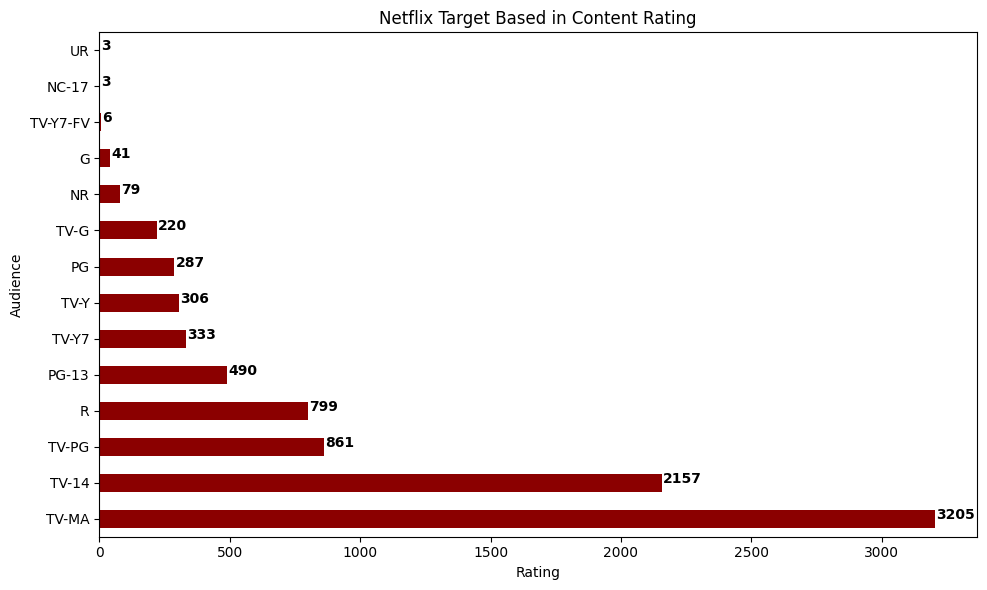

In [28]:
ax = ratings.plot(kind = "barh",
                         title = "Netflix Target Based in Content Rating",
                         xlabel = "Rating",
                         ylabel = "Audience",
                         color = "darkred",
                         figsize = (10,6))

for i, v in enumerate(ratings):
  ax.text(v+5, i, f"{v}", ha="left", fontweight="bold")

plt.tight_layout()
plt.show()

##Business Insight:
Netflix's catalog is heavily skewed toward mature and older teen audiences. While this reflects a clear strategic focus on adult content, it also reveals an underserved opportunity in family and children's programming, categories like TV-G, TV-Y, and TV-Y7 represent a small fraction of the catalog and could be expanded to attract a broader subscriber base.

#Which genres have the highest representation and which are underserved in the catalog?

In [29]:
genres = df["listed_in"].str.split(", ").explode().value_counts().head(15)
print(genres)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  573
Crime TV Shows               469
Kids' TV                     448
Docuseries                   394
Name: count, dtype: int64


##Finding:
International Movies and Dramas are the most represented genres in Netflix's catalog, with 2,752 and 2,426 titles respectively. It is worth noting that "International Movies" is a broad label that groups content from multiple non-American countries, which may inflate its numbers. Among clearly defined genres, Comedies (1,674) and Action & Adventure (859) are the strongest performers, while Kids' TV (448) and Docuseries (394) are the least represented in the top 15.

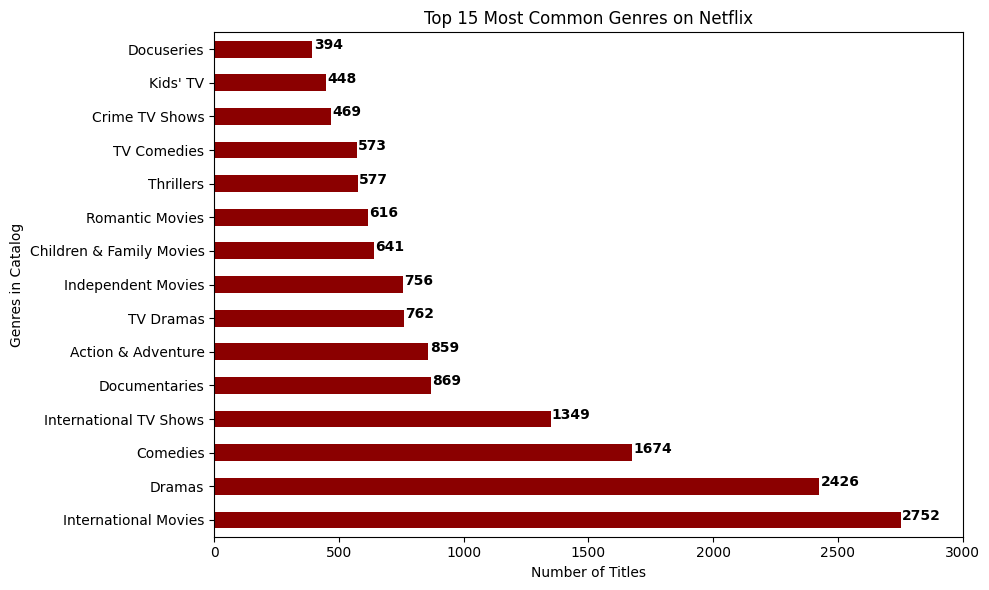

In [33]:
ax = genres.plot(kind = "barh",
            title = "Top 15 Most Common Genres on Netflix",
            xlabel = "Number of Titles",
            ylabel = "Genres in Catalog",
            color = "darkred",
            figsize = (10,6))

for i, v in enumerate(genres):
  ax.text(v+5, i, f"{v}", ha="left", fontweight="bold")

plt.xlim(0,3000)
plt.tight_layout()
plt.show()

##Business Insight:
Netflix's catalog is heavily concentrated in International Movies and Dramas, suggesting a strong focus on broad, globally appealing content. Kids' TV and Docuseries are significantly underrepresented, indicating potential growth opportunities in family entertainment and documentary content — categories that could attract new subscriber segments and diversify the platform's appeal.

#Conclusions
The analysis of Netflix's catalog reveals several strategic patterns. Content additions grew rapidly between 2016 and 2019, peaking at over 2,000 titles, but have slowed since then, suggesting a potential shift toward quality over quantity. Movies continue to dominate the catalog over TV Shows, though serialized content has grown steadily since 2016. The United States is by far the largest content producer, while countries like Japan, South Korea, and Spain represent emerging opportunities for local production investment. In terms of audience targeting, Netflix primarily serves mature and older teen audiences, with family and children's content remaining underserved. Finally, International Movies and Dramas lead the catalog by genre, while Kids' TV and Docuseries present untapped growth opportunities to attract broader subscriber segments.